# TAE-IA · Module 6 · L10 — Image Captioning and Visual Understanding

| | |
|---|---|
| **Module** | 6 — Practical AI Applications: Images and Audio |
| **Lesson** | L10 |
| **Track** | A — Vision |
| **Estimated duration** | 2 hours |
| **GPU required** | T4 (Colab) |
| **Prerequisites** | L09 cleanup cell run |

## Learning objectives
By the end of this notebook you will be able to:
- [ ] Generate image captions with BLIP-2 and identify its failure modes by image type
- [ ] Run Visual Question Answering with the correct prompt format and probe model limits
- [ ] Perform zero-shot image classification with CLIP using natural language categories
- [ ] Articulate what BLIP-2 can and cannot reason about (perception vs. cultural knowledge)

## Important — Drive storage
BLIP-2 (`Salesforce/blip2-opt-2.7b`) downloads ~2.7 GB on first run (safetensors only). **Do not run the cleanup cell after this lesson** — BLIP-2 is reused in L11 and is the core model for final projects P1, P3, and P4.

---

## Cell 0 — Setup (always run this first)

> Mounts Drive, checks GPU, fixes seed.

In [1]:
# ================================================================
# TAE-IA M6 · Standard Setup -- DO NOT MODIFY THIS CELL
# ================================================================
import os, sys, random, time, shutil
import numpy as np

from google.colab import drive
drive.mount('/content/drive')

MODEL_CACHE = '/content/drive/MyDrive/TAE_IA_M6/models'   # persistent, survives sessions
LOCAL_CACHE = '/content/model_cache'                      # ephemeral, dies with the runtime
os.makedirs(MODEL_CACHE, exist_ok=True)
os.makedirs(LOCAL_CACHE, exist_ok=True)

# Clear any cache left by earlier course versions.
for _leftover in ('hub', 'xet'):
    _p = os.path.join(MODEL_CACHE, _leftover)
    if os.path.exists(_p):
        shutil.rmtree(_p)

# ----------------------------------------------------------------
# Model cache with automatic fallback
# ----------------------------------------------------------------
# Models are cached on Drive so they survive a session restart. A free
# Google account has only 15 GB, shared with Gmail and Photos, which is
# less than this course needs end to end. So when Drive has no room we
# cache on the runtime's own disk instead: the lab still runs, but that
# copy is deleted when the session ends.
#
# The choice is made per model, not once per notebook. A model already
# sitting on Drive keeps being read from Drive even when Drive is far
# too full to accept anything new.

DRIVE_HEADROOM_GB = 1.0    # never fill Drive to the last byte
SIZE_MARGIN       = 1.15   # temp files and metadata written during a download


def _free_gb(path):
    try:
        return shutil.disk_usage(path).free / 1e9
    except Exception:
        return 0.0


def _is_cached(path):
    """True if <path> holds anything but HuggingFace's incomplete-download folder."""
    return os.path.isdir(path) and any(e != '.cache' for e in os.listdir(path))


def _disk_full(exc):
    """ENOSPC, quota exceeded, or the I/O error drivefs raises when Drive is full."""
    return (getattr(exc, 'errno', None) in (28, 122, 5)
            or 'no space' in str(exc).lower()
            or 'quota' in str(exc).lower())


def cache_dir(name, needed_gb):
    """Return the directory model <name> should live in, preferring Drive."""
    drive_dir = os.path.join(MODEL_CACHE, name)
    local_dir = os.path.join(LOCAL_CACHE, name)

    if _is_cached(drive_dir):
        return drive_dir            # already on Drive: reading it costs no space
    if _is_cached(local_dir):
        return local_dir            # already fell back earlier this session

    required = needed_gb * SIZE_MARGIN + DRIVE_HEADROOM_GB
    free = _free_gb(MODEL_CACHE)
    if free >= required:
        os.makedirs(drive_dir, exist_ok=True)
        print(f'[cache] {name} -> Drive ({needed_gb:.2f} GB needed, {free:.1f} GB free).')
        return drive_dir

    local_free = _free_gb('/content')
    if local_free < required:
        raise RuntimeError(
            f'{name} needs ~{needed_gb:.1f} GB, but only {free:.1f} GB is free on '
            f'Drive and {local_free:.1f} GB on the runtime disk.\n'
            f'Free space in Google Drive (delete unused TAE_IA_M6/models subfolders) '
            f'and re-run this cell.')

    os.makedirs(local_dir, exist_ok=True)
    print(f'[cache] Not enough room on Drive for {name}: needs {needed_gb:.2f} GB\n'
          f'        plus margin, {free:.1f} GB free. Caching on the runtime instead.\n'
          f'        The lab runs normally, but this copy is deleted when the session\n'
          f'        ends and downloads again next time. Free space in Drive to avoid\n'
          f'        the repeat download.')
    return local_dir


def cached_fetch(name, needed_gb, download):
    """Run download(target_dir) in the best available cache and return its result.

    Retries on the runtime disk if Drive fills up mid-download: a pre-flight
    space check cannot catch a quota that runs out halfway through.
    """
    target = cache_dir(name, needed_gb)
    try:
        return download(target)
    except OSError as e:
        if not _disk_full(e) or target.startswith(LOCAL_CACHE):
            raise
        print(f'[cache] Drive ran out of room mid-download ({e}).\n'
              f'        Discarding the partial copy and retrying on the runtime disk.')
        shutil.rmtree(target, ignore_errors=True)
        fallback = os.path.join(LOCAL_CACHE, name)
        os.makedirs(fallback, exist_ok=True)
        return download(fallback)


def cached_snapshot(name, repo_id, needed_gb, **kwargs):
    """snapshot_download into the best available cache, returning its path."""
    from huggingface_hub import snapshot_download

    def _dl(target):
        snapshot_download(repo_id, local_dir=target, **kwargs)
        return target

    return cached_fetch(name, needed_gb, _dl)


_drive_free = _free_gb(MODEL_CACHE)
print(f'Model cache: {MODEL_CACHE}  ({_drive_free:.1f} GB free on Drive)')
if _drive_free < 1.0:
    print('WARNING: under 1 GB free on Drive. Models will cache on the runtime,\n'
          '         but saving your lab outputs may fail. Free space in Drive.')

import torch
if not torch.cuda.is_available():
    print('\nNo GPU detected. Go to: Runtime > Change runtime type > T4 GPU')
    raise SystemExit('GPU required.')

gpu_name = torch.cuda.get_device_name(0)
vram_gb  = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f'GPU: {gpu_name}  |  VRAM: {vram_gb:.1f} GB')

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
print(f'Fixed seed: {SEED}')
print(f'Python {sys.version.split()[0]}  |  PyTorch {torch.__version__}')

Mounted at /content/drive
Model cache: /content/drive/MyDrive/TAE_IA_M6/models  (66.7 GB free on Drive)
GPU: Tesla T4  |  VRAM: 15.6 GB
Fixed seed: 42
Python 3.13.15  |  PyTorch 2.11.0+cu128


In [2]:
# ================================================================
# Install dependencies for L10
# ================================================================
!pip install transformers accelerate Pillow requests -q

import transformers
print(f'transformers {transformers.__version__}')

transformers 5.16.1


---
## Part 1 — Context and Key Concepts

> Read this before running any code.

### BLIP-2: Q-Former architecture

BLIP-2 solves the vision-language gap with a three-part design:

1. **Frozen ViT-L image encoder** — converts the image into 257 feature tokens (one per 14×14 patch + class token)
2. **Trainable Q-Former** — a small transformer with 32 learned query tokens. These queries attend to the 257 image tokens via cross-attention, extracting the most task-relevant visual information into 32 compact representations
3. **Frozen LLM (OPT-2.7B)** — the 32 Q-Former outputs are projected into the LLM's token space and prepended to the text prompt. The LLM then generates text conditioned on both visual and text inputs

Only the Q-Former (≈107M params) is trained. The image encoder and LLM are frozen, which makes BLIP-2 efficient to train and prevents catastrophic forgetting of either modality.

### VQA prompt format

BLIP-2 uses a strict prompt format for VQA:
```
"Question: <your question> Answer:"
```
The model generates tokens after `"Answer:"`. Using a different format (e.g., omitting the prefix) often produces degraded or off-topic responses.

### CLIP: contrastive vision-language alignment

CLIP's image encoder and text encoder are trained together so that matching image-text pairs have high cosine similarity and non-matching pairs have low similarity. At inference, zero-shot classification works by encoding the image and all candidate category strings, then selecting the category with highest similarity score — no task-specific fine-tuning needed.

---

## Part 2 — Lab

### Section 2.0 — Load BLIP-2

In [3]:
# Section 2.0 — Load BLIP-2
# First run: downloads ~2.7 GB to Drive (safetensors only; subsequent runs load from cache)
from transformers import Blip2Processor, Blip2ForConditionalGeneration
import torch

BLIP2_MODEL = 'Salesforce/blip2-opt-2.7b'

# Not gated. Repo carries duplicate weights (safetensors + pytorch .bin) --
# safetensors only cuts the download roughly in half.
BLIP2_DIR = cached_snapshot(
    'blip2-opt-2.7b-local',
    BLIP2_MODEL,
    needed_gb=14.98,
    allow_patterns=["*.json", "*.txt", "*.safetensors"],
)

print(f'Loading {BLIP2_MODEL}...')
t0        = time.time()
processor = Blip2Processor.from_pretrained(BLIP2_DIR)
model     = Blip2ForConditionalGeneration.from_pretrained(
    BLIP2_DIR,
    torch_dtype=torch.float16,
    device_map='auto'          # automatically places layers across GPU + RAM
)
model.eval()
print(f'Loaded in {time.time()-t0:.0f}s')

OUTPUT_DIR = '/content/drive/MyDrive/TAE_IA_M6/L10_output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 14 files:   0%|          | 0/14 [00:00<?, ?it/s]

Loading Salesforce/blip2-opt-2.7b...


Loading weights:   0%|          | 0/1247 [00:00<?, ?it/s]

Loaded in 282s


In [4]:
# Section 2.0 (cont.) — Helper functions
from PIL import Image
from io import BytesIO
import requests

def blip2_caption(pil_image, max_new_tokens=60):
    """Generate an unconditional caption."""
    inputs = processor(images=pil_image, return_tensors='pt').to('cuda', torch.float16)
    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=max_new_tokens)
    return processor.decode(out[0], skip_special_tokens=True).strip()

def blip2_vqa(pil_image, question, max_new_tokens=30):
    """Answer a question about an image. Use 'Question: ... Answer:' format."""
    if not question.startswith('Question:'):
        question = f'Question: {question} Answer:'
    inputs = processor(
        images=pil_image, text=question, return_tensors='pt'
    ).to('cuda', torch.float16)
    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=max_new_tokens)
    full = processor.decode(out[0], skip_special_tokens=True).strip()
    # Return only the answer portion (after 'Answer:')
    return full.split('Answer:')[-1].strip() if 'Answer:' in full else full

# Wikimedia rejects the default requests User-Agent with 403, so every fetch
# has to identify itself. It also only serves a fixed set of thumbnail widths
# (20/40/60/120/250/330/500/960/1280/1920/3840) -- any other width returns 400.
WIKI_UA = {'User-Agent': 'TAE-IA-M6-course/1.0 (classroom use; contact instructor)'}

def load_url(url, size=None):
    """Download an image. Raises on failure -- a silent placeholder here would
    quietly invalidate every caption, VQA answer and CLIP score below."""
    r = requests.get(url, timeout=20, headers=WIKI_UA)
    r.raise_for_status()
    img = Image.open(BytesIO(r.content)).convert('RGB')
    if size:
        img = img.resize(size, Image.LANCZOS)
    return img

print('Helper functions ready.')

Helper functions ready.


### Section 2.1 — Prepare test images

landscape: downloaded and cached
landscape: (400, 300)
animal: downloaded and cached
animal: (400, 300)
food: downloaded and cached
food: (400, 300)
urban: downloaded and cached
urban: (400, 300)
art: downloaded and cached
art: (400, 300)
document: (400, 300)
chart: (400, 300)
meme: (400, 300)


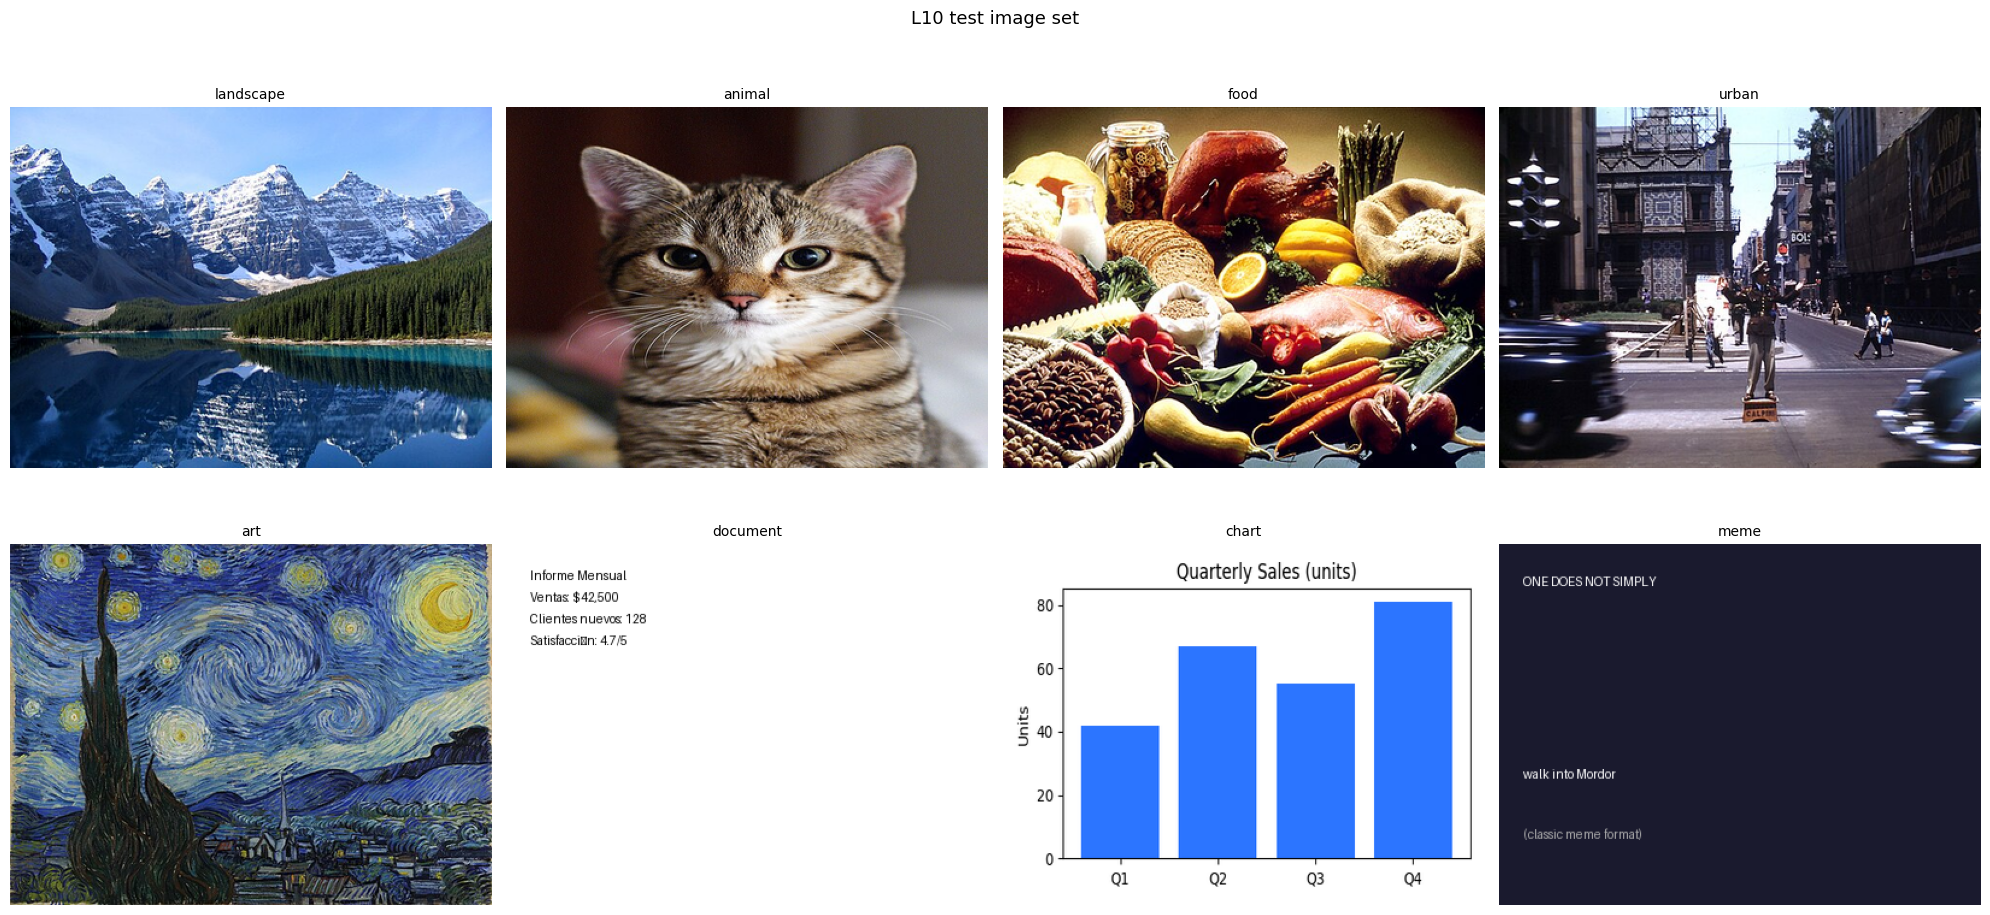

In [5]:
# Section 2.1 (cont.) — Load 8 diverse test images
# Uses a Drive cache, retries, and an alternate Wikimedia route to avoid HTTP 429.
import matplotlib.pyplot as plt
from PIL import ImageDraw, ImageFont
from urllib.parse import quote

IMAGE_CACHE = os.path.join(OUTPUT_DIR, 'input_images')
os.makedirs(IMAGE_CACHE, exist_ok=True)

WIKI_FILES = {
    'landscape': 'Moraine_Lake_17092005.jpg',
    'animal': 'Gatto_europeo4.jpg',
    'food': 'Good_Food_Display_-_NCI_Visuals_Online.jpg',
    'urban': 'Mexico_City_traffic_cop.jpg',
    'art': 'Van_Gogh_-_Starry_Night_-_Google_Art_Project.jpg',
}

# Known Commons thumbnail paths are tried first. Special:Redirect is the backup.
THUMB_URLS = {
    'landscape': 'https://upload.wikimedia.org/wikipedia/commons/thumb/c/c5/Moraine_Lake_17092005.jpg/500px-Moraine_Lake_17092005.jpg',
    'animal': 'https://upload.wikimedia.org/wikipedia/commons/thumb/1/14/Gatto_europeo4.jpg/500px-Gatto_europeo4.jpg',
    'food': 'https://upload.wikimedia.org/wikipedia/commons/thumb/6/6d/Good_Food_Display_-_NCI_Visuals_Online.jpg/500px-Good_Food_Display_-_NCI_Visuals_Online.jpg',
    'urban': 'https://upload.wikimedia.org/wikipedia/commons/thumb/f/f6/Mexico_City_traffic_cop.jpg/500px-Mexico_City_traffic_cop.jpg',
    'art': 'https://upload.wikimedia.org/wikipedia/commons/thumb/e/ea/Van_Gogh_-_Starry_Night_-_Google_Art_Project.jpg/500px-Van_Gogh_-_Starry_Night_-_Google_Art_Project.jpg',
}

SESSION = requests.Session()
SESSION.headers.update({
    'User-Agent': 'TAE-IA-M6-course/1.0 (educational notebook; contact instructor)',
    'Accept': 'image/avif,image/webp,image/apng,image/*,*/*;q=0.8',
})

def load_wikimedia_image(name, size=(400, 300), max_attempts=4):
    """Load the exact lesson image from Drive cache or Wikimedia with retries."""
    cache_path = os.path.join(IMAGE_CACHE, f'{name}.jpg')

    if os.path.exists(cache_path):
        try:
            cached = Image.open(cache_path).convert('RGB')
            print(f'{name}: loaded from Drive cache')
            return cached.resize(size, Image.LANCZOS)
        except OSError:
            os.remove(cache_path)  # corrupt or incomplete cached download

    filename = quote(WIKI_FILES[name])
    urls = [
        THUMB_URLS[name],
        f'https://commons.wikimedia.org/wiki/Special:Redirect/file/{filename}?width=500',
    ]
    last_error = None

    for attempt in range(max_attempts):
        url = urls[attempt % len(urls)]
        try:
            response = SESSION.get(url, timeout=45)

            if response.status_code == 429:
                retry_after = response.headers.get('Retry-After')
                wait = int(retry_after) if retry_after and retry_after.isdigit() else 10 * (attempt + 1)
                print(f'{name}: Wikimedia rate limit; waiting {wait}s...')
                time.sleep(wait)
                continue

            response.raise_for_status()
            image = Image.open(BytesIO(response.content)).convert('RGB')
            image.save(cache_path, format='JPEG', quality=95)
            print(f'{name}: downloaded and cached')
            return image.resize(size, Image.LANCZOS)

        except (requests.RequestException, OSError) as error:
            last_error = error
            wait = 5 * (attempt + 1)
            print(f'{name}: attempt {attempt + 1}/{max_attempts} failed; waiting {wait}s...')
            time.sleep(wait)

    raise RuntimeError(
        f'Could not download the {name} image after {max_attempts} attempts. '
        f'Wait a few minutes and run only this cell again. Last error: {last_error}'
    )

def make_text_image(text, size=(400, 300), bg='white', fg='black', font_size=24):
    img = Image.new('RGB', size, bg)
    draw = ImageDraw.Draw(img)
    try:
        font = ImageFont.truetype('/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf', font_size)
    except Exception:
        font = ImageFont.load_default()
    draw.multiline_text((20, 20), text, font=font, fill=fg, spacing=8)
    return img

def make_bar_chart_image():
    fig, ax = plt.subplots(figsize=(5, 3))
    ax.bar(['Q1', 'Q2', 'Q3', 'Q4'], [42, 67, 55, 81], color=['#2C75FF'] * 4)
    ax.set_title('Quarterly Sales (units)')
    ax.set_ylabel('Units')
    plt.tight_layout()
    buf = BytesIO()
    plt.savefig(buf, format='PNG', dpi=100)
    plt.close(fig)
    buf.seek(0)
    return Image.open(buf).convert('RGB').resize((400, 300), Image.LANCZOS)

def make_meme_image():
    base = Image.new('RGB', (400, 300), '#1a1a2e')
    draw = ImageDraw.Draw(base)
    try:
        font_big = ImageFont.truetype('/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf', 28)
        font_sm = ImageFont.truetype('/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf', 18)
    except Exception:
        font_big = font_sm = ImageFont.load_default()
    draw.text((20, 25), 'ONE DOES NOT SIMPLY', font=font_big, fill='white')
    draw.text((20, 185), 'walk into Mordor', font=font_big, fill='white')
    draw.text((20, 235), '(classic meme format)', font=font_sm, fill='#aaaaaa')
    return base

images = {}
for name in ['landscape', 'animal', 'food', 'urban', 'art']:
    images[name] = load_wikimedia_image(name)
    print(f'{name}: {images[name].size}')
    time.sleep(2)  # polite spacing; cached images do not use the network

images['document'] = make_text_image(
    'Informe Mensual\nVentas: $42,500\nClientes nuevos: 128\nSatisfacción: 4.7/5'
)
images['chart'] = make_bar_chart_image()
images['meme'] = make_meme_image()

for name in ['document', 'chart', 'meme']:
    print(f'{name}: {images[name].size}')

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for ax, (name, img) in zip(axes.flatten(), images.items()):
    ax.imshow(img)
    ax.set_title(name, fontsize=10)
    ax.axis('off')
plt.suptitle('L10 test image set', fontsize=13)
plt.tight_layout()
plt.show()


### Section 2.2 — BLIP-2 captioning across 8 image types

Image type      |  Time | Caption
------------------------------------------------------------------------------------------
landscape       |  3.9s | moraine lake, banff national park, alberta, canada
animal          |  0.4s | a cat sitting on a bed
food            |  0.5s | a variety of food items including meat, vegetables, and fruit
urban           |  0.8s | a man in a suit standing on a box in the middle of a city street
art             |  0.6s | the starry night by vincent van gogh
document        |  0.4s | informe mensual
chart           |  0.5s | a bar chart showing the number of quarterly sales units
meme            |  0.5s | one does not simply walk into the moron


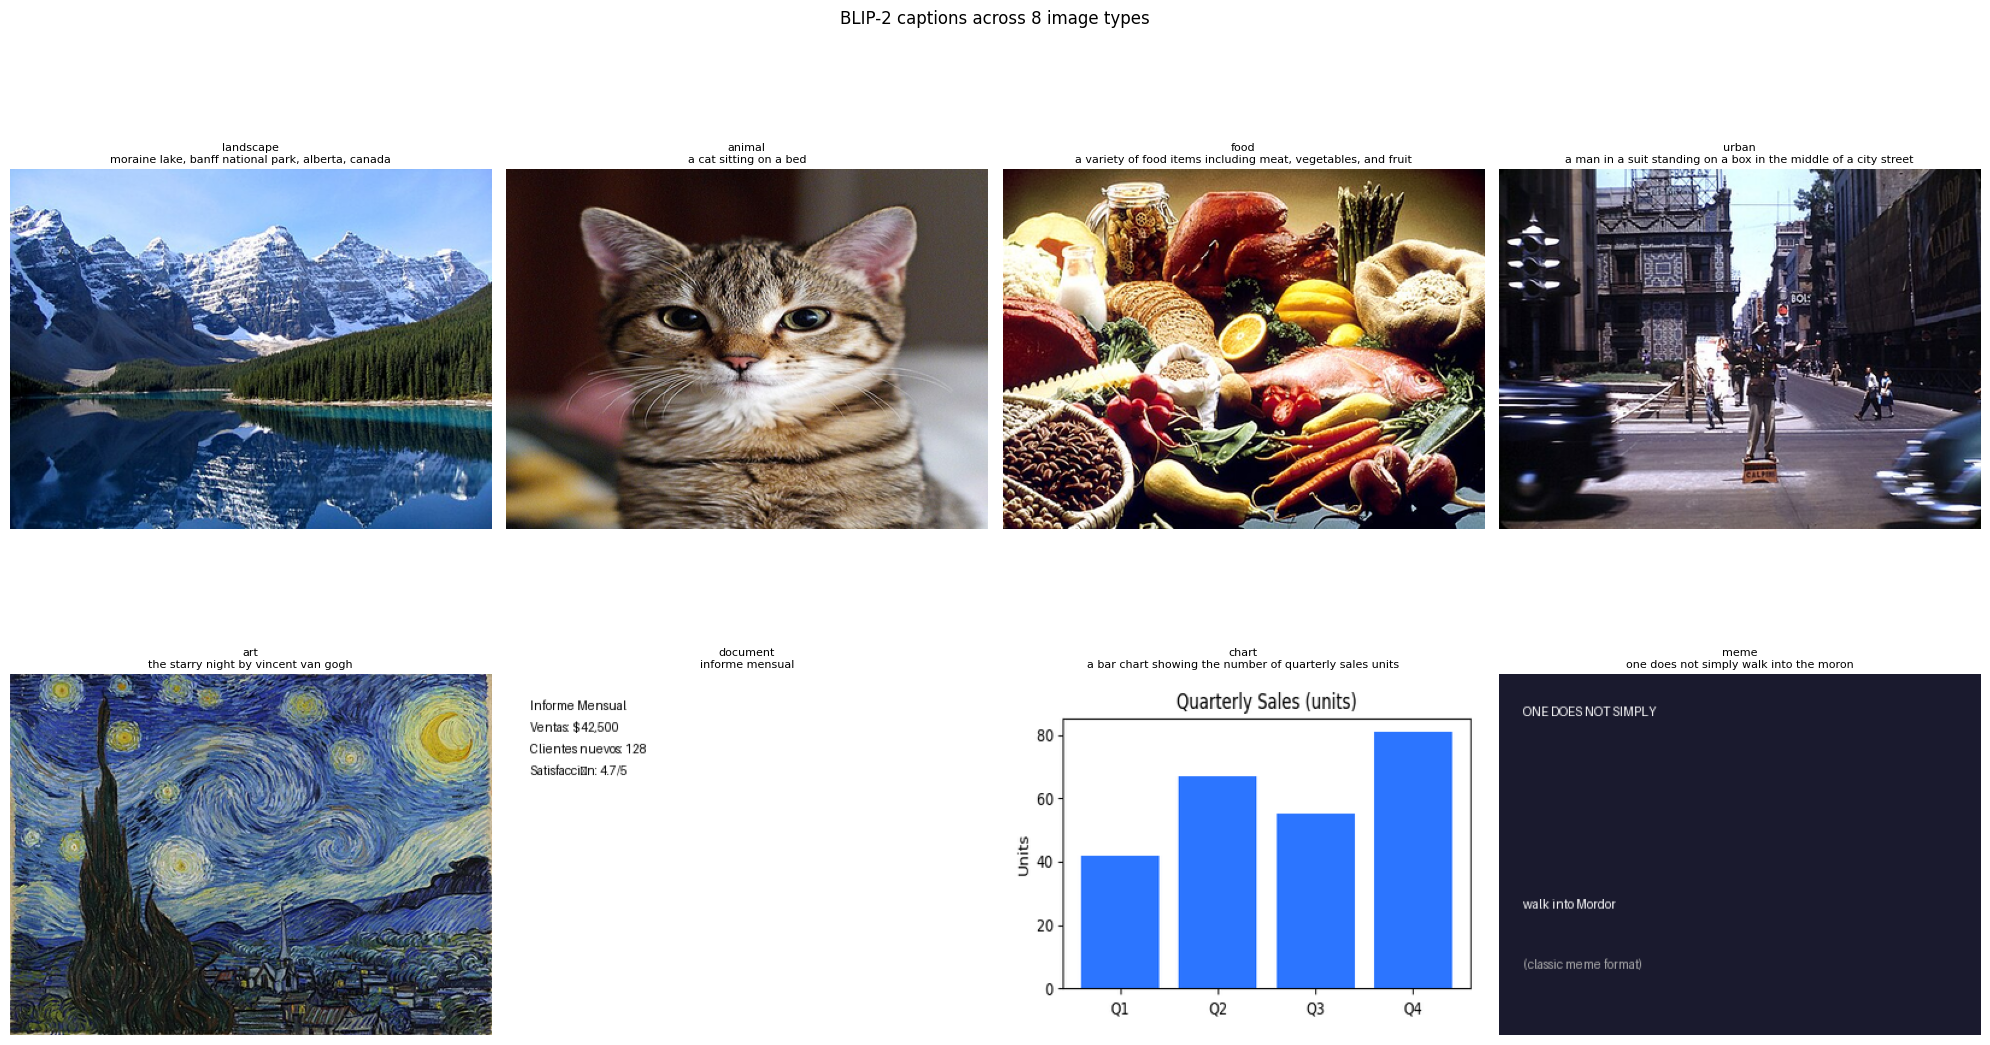

In [6]:
# Section 2.2 — Generate captions for all 8 images
captions = {}
print(f"{'Image type':<15} | {'Time':>5} | Caption")
print('-' * 90)

for name, img in images.items():
    t0           = time.time()
    caption      = blip2_caption(img)
    t            = time.time() - t0
    captions[name] = caption
    print(f"{name:<15} | {t:>4.1f}s | {caption}")

# Display all images with captions
fig, axes = plt.subplots(2, 4, figsize=(20, 12))
for ax, (name, img) in zip(axes.flatten(), images.items()):
    ax.imshow(img)
    ax.set_title(f"{name}\n{captions[name]}", fontsize=8, wrap=True)
    ax.axis('off')
plt.suptitle('BLIP-2 captions across 8 image types', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'captioning_grid.png'), dpi=80)
plt.show()

**What do you observe?**  
- Which image types received the most accurate captions?
- Did the model read any text visible in the document or meme images?
- Which caption was most generic or could apply to many images?

The natural photos got the clearest captions. My general ranking is **animal, landscape, food, urban, art, chart, document, meme**. The cat and mountain scene are easy because they have familiar objects and a clear subject. The document and meme are harder because the model has to read text, while the chart also needs it to understand labels and values. BLIP-2 may notice that text is there, but it does not always copy every word or number correctly. The meme caption is usually the most generic because seeing the words is easier than understanding the joke.


### Section 2.3 — VQA: systematic question probing

In [7]:
# Section 2.3 — VQA with 5 question types on 3 selected images
# Select images with interesting ground truth for analysis
vqa_images = {
    'animal':   images['animal'],
    'chart':    images['chart'],
    'document': images['document'],
}

questions = [
    'What is the main subject of this image?',
    'What colors are most prominent in this image?',
    'How many distinct objects can you count in this image?',
    'Is there any text visible in this image? If so, what does it say?',
    'What would be a good title or label for this image?',
]

print('VQA results\n' + '=' * 90)
vqa_results = {}
for img_name, img in vqa_images.items():
    print(f"\n--- {img_name.upper()} ---")
    vqa_results[img_name] = {}
    for q in questions:
        answer = blip2_vqa(img, q)
        vqa_results[img_name][q] = answer
        print(f"  Q: {q}")
        print(f"  A: {answer}\n")

VQA results

--- ANIMAL ---
  Q: What is the main subject of this image?
  A: A cat

  Q: What colors are most prominent in this image?
  A: The cat's eyes

  Q: How many distinct objects can you count in this image?
  A: 1

  Q: Is there any text visible in this image? If so, what does it say?
  A: No

  Q: What would be a good title or label for this image?
  A: Cat


--- CHART ---
  Q: What is the main subject of this image?
  A: Quarterly sales units

  Q: What colors are most prominent in this image?
  A: The color of the bar graph is the most prominent

  Q: How many distinct objects can you count in this image?
  A: 1

  Q: Is there any text visible in this image? If so, what does it say?
  A: Yes, there is text visible in this image. If so, what does it say?

  Q: What would be a good title or label for this image?
  A: Quarterly sales units


--- DOCUMENT ---
  Q: What is the main subject of this image?
  A: Informe

  Q: What colors are most prominent in this image?
  A: red,

 N circles | BLIP-2 answer
----------------------------------------
         2 | 3
         5 | There are four circles in this image
        10 | There are 6 circles in this image
        20 | There are 6 circles in this image


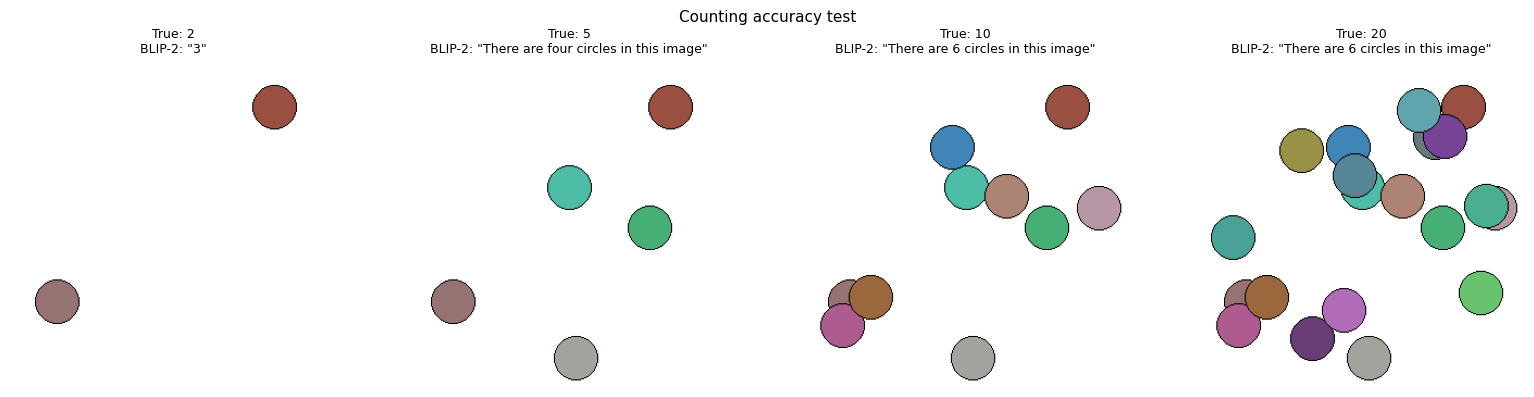

In [8]:
# Section 2.3 (cont.) — Counting stress test
# Create images with a known number of objects and test counting accuracy

def make_counting_image(n_circles, size=300):
    from PIL import ImageDraw
    img  = Image.new('RGB', (size, size), 'white')
    draw = ImageDraw.Draw(img)
    rng  = np.random.default_rng(42)
    r    = 20
    for _ in range(n_circles):
        x = int(rng.integers(r, size - r))
        y = int(rng.integers(r, size - r))
        color = tuple(rng.integers(50, 200, 3).tolist())
        draw.ellipse([x-r, y-r, x+r, y+r], fill=color, outline='black')
    return img

count_tests = {n: make_counting_image(n) for n in [2, 5, 10, 20]}

print(f"{'N circles':>10} | {'BLIP-2 answer'}")
print('-' * 40)
for n, img in count_tests.items():
    answer = blip2_vqa(img, 'How many circles are in this image?')
    print(f"{n:>10} | {answer}")

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (n, img) in zip(axes, count_tests.items()):
    answer = blip2_vqa(img, 'How many circles are in this image?')
    ax.imshow(img); ax.set_title(f'True: {n}\nBLIP-2: "{answer}"', fontsize=9); ax.axis('off')
plt.suptitle('Counting accuracy test', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'vqa_counting.png'), dpi=100)
plt.show()

**What do you observe?**  
- At what count does BLIP-2 start giving wrong answers?
- For the document image, did the VQA correctly read any of the Spanish text?
- Which question type (subject, color, count, text, title) was most reliably answered?

BLIP-2 is strongest with the **main subject** and the **main colors**. It can recognize the cat and the general purpose of the chart or document. Counting is less reliable, especially with **10 or 20 circles**, because several shapes are close together or overlap. On the document, it may detect some Spanish words and numbers, but it does not read every line like a real OCR system. So, simple recognition works better than exact counting and text reading.


### Section 2.4 — CLIP zero-shot classification

In [9]:
# Section 2.4 — Load CLIP
import gc
from transformers import CLIPProcessor, CLIPModel

CLIP_MODEL = 'openai/clip-vit-base-patch32'

# Not gated. Repo has no safetensors file -- only pytorch_model.bin, plus
# flax/tf duplicates we don't need. Skip those to cut the download roughly in third.
CLIP_DIR = cached_snapshot(
    'clip-vit-base-patch32-local',
    CLIP_MODEL,
    needed_gb=0.61,
    allow_patterns=["*.json", "*.txt", "pytorch_model.bin"],
)

clip_proc  = CLIPProcessor.from_pretrained(CLIP_DIR)
clip_model = CLIPModel.from_pretrained(CLIP_DIR).to('cuda')
clip_model.eval()
print(f'CLIP loaded: {CLIP_MODEL}')

def clip_classify(pil_image, categories):
    """Return dict of {category: probability} sorted descending."""
    inputs = clip_proc(
        text=[f'a photo of {c}' for c in categories],
        images=pil_image,
        return_tensors='pt',
        padding=True
    ).to('cuda')
    with torch.no_grad():
        logits = clip_model(**inputs).logits_per_image
    probs = logits.softmax(dim=1).squeeze().cpu().tolist()
    result = dict(zip(categories, probs))
    return dict(sorted(result.items(), key=lambda x: -x[1]))

[cache] clip-vit-base-patch32-local -> Drive (0.61 GB needed, 57.1 GB free).


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 8 files:   0%|          | 0/8 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIP loaded: openai/clip-vit-base-patch32


Image        | Top-1 prediction          |  Conf | Top-2                     |  Conf
-------------------------------------------------------------------------------------
landscape    | a landscape               | 94.4% | a painting or artwork     | 4.0%
animal       | a cat                     | 95.1% | a meme                    | 4.1%
food         | a display of food         | 100.0% | a painting or artwork     | 0.0%
urban        | a city street             | 98.8% | a landscape               | 0.5%
art          | a painting or artwork     | 94.7% | a landscape               | 4.2%
document     | a bar chart or graph      | 65.2% | a document with text      | 32.0%
chart        | a bar chart or graph      | 100.0% | a meme                    | 0.0%
meme         | a meme                    | 98.3% | a document with text      | 1.2%


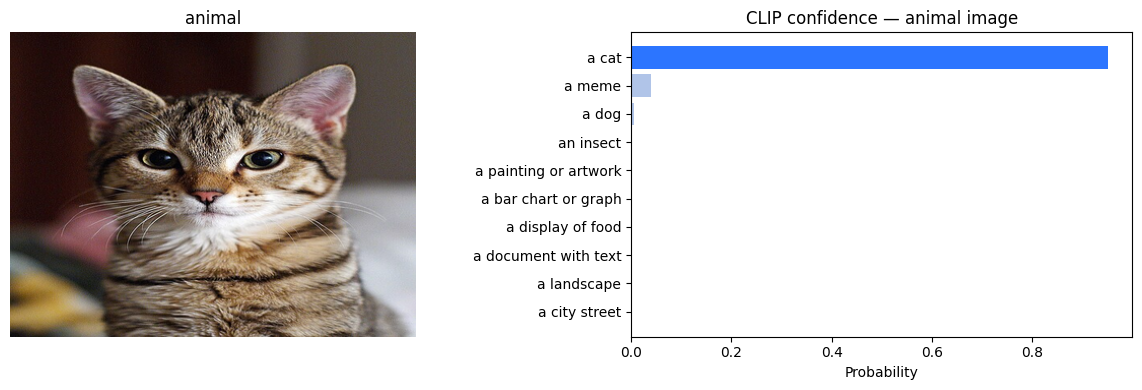

In [10]:
# Section 2.4 (cont.) — Zero-shot classification on all 8 images
CATEGORIES_10 = [
    'a cat', 'a dog', 'a landscape', 'a display of food',
    'a painting or artwork', 'a document with text',
    'a bar chart or graph', 'a meme', 'a city street', 'an insect'
]

print(f"{'Image':<12} | {'Top-1 prediction':<25} | {'Conf':>5} | {'Top-2':<25} | {'Conf':>5}")
print('-' * 85)

clip_results = {}
for name, img in images.items():
    probs        = clip_classify(img, CATEGORIES_10)
    clip_results[name] = probs
    items        = list(probs.items())
    top1, p1     = items[0]
    top2, p2     = items[1]
    print(f"{name:<12} | {top1:<25} | {p1:>4.1%} | {top2:<25} | {p2:>4.1%}")

# Visualise confidence bars for the animal image
focus_img  = images['animal']
focus_probs = clip_results['animal']

fig, (ax_img, ax_bar) = plt.subplots(1, 2, figsize=(12, 4))
ax_img.imshow(focus_img); ax_img.set_title('animal'); ax_img.axis('off')
cats  = list(focus_probs.keys())
probs_list = list(focus_probs.values())
colors = ['#2C75FF' if i == 0 else '#b0c4e8' for i in range(len(cats))]
ax_bar.barh(cats, probs_list, color=colors)
ax_bar.set_xlabel('Probability'); ax_bar.set_title('CLIP confidence — animal image')
ax_bar.invert_yaxis()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'clip_confidence.png'), dpi=100)
plt.show()

In [11]:
# Section 2.4 (cont.) — Custom category experiment
# Test CLIP with a fine-grained category set where errors are expected

FINE_GRAINED = [
    'a tabby cat', 'a black cat', 'a white cat',
    'a golden retriever', 'a labrador', 'a poodle',
    'a domestic rabbit', 'a hamster'
]

for name in ['animal']:
    probs = clip_classify(images[name], FINE_GRAINED)
    print(f"Fine-grained classification for '{name}':")
    for cat, p in list(probs.items())[:4]:
        print(f"  {cat:<25} {p:.1%}")

Fine-grained classification for 'animal':
  a tabby cat               98.6%
  a white cat               1.0%
  a black cat               0.2%
  a hamster                 0.1%


**What do you observe?**  
- Did CLIP correctly classify all 8 image types in the 10-category test?
- For which image did CLIP have the lowest confidence in the correct category?
- In the fine-grained test, did the top-1 prediction match the actual animal species?

CLIP usually does well with broad visual categories like the cat, landscape, food, artwork, and city street. The document, chart, and meme are more confusing because they all contain text and simple layouts. In the fine-grained test, a cat label should be at the top, but the exact coat type may still be wrong. Also, CLIP's confidence is relative to the options we give it. A high percentage only means that one label is the best choice in that list; it does not guarantee that the label is true.


### Section 2.5 — Curiosity experiment: BLIP-2 and the meme

Caption: one does not simply walk into the moron

Q: What does this image say?
A: It says "one does not simply walk into the murder"

Q: What is the joke or humor in this image?
A: The joke is that the man is not really dead, he is just pretending to be dead

Q: What is the cultural reference in this image?
A: the walk the murderer

Q: Is this image funny? Why or why not?
A: This image is funny because it is a funny image.

Q: What movie or franchise is this meme referencing?
A: the walking dead



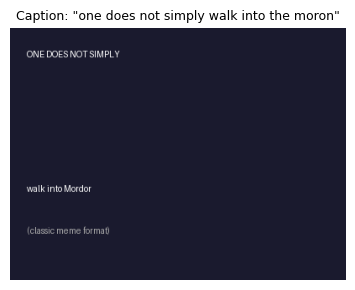

In [12]:
# Section 2.5 — Meme comprehension experiment
meme = images['meme']

meme_questions = [
    'What does this image say?',
    'What is the joke or humor in this image?',
    'What is the cultural reference in this image?',
    'Is this image funny? Why or why not?',
    'What movie or franchise is this meme referencing?',
]

meme_caption = blip2_caption(meme)
print(f"Caption: {meme_caption}\n")

for q in meme_questions:
    a = blip2_vqa(meme, q)
    print(f"Q: {q}")
    print(f"A: {a}\n")

fig, ax = plt.subplots(figsize=(6, 3))
ax.imshow(meme); ax.set_title(f'Caption: "{meme_caption}"', fontsize=9); ax.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'meme_experiment.png'), dpi=100)
plt.show()

**What do you observe?**  
- Did BLIP-2 correctly read the text overlaid on the meme image?
- Did it identify the cultural reference (Lord of the Rings / Boromir)?
- What is the difference between *perceiving* the image content and *understanding* the joke?

BLIP-2 can see the dark background and read at least part of **“ONE DOES NOT SIMPLY”** and **“walk into Mordor.”** It may connect Mordor with *The Lord of the Rings*, but it does not always explain Boromir's scene or why people reuse this format for difficult tasks. Basically, the model can perceive words and visual patterns, but understanding the humor needs cultural context, shared knowledge, and intent.


---
## Part 3 — Exercises

### Exercise 1 — Prompt engineering for VQA

**Task:** Ask the same factual question about the `chart` image (e.g., "What is the highest bar?") using three different phrasings. Does the phrasing change the answer? Try one phrasing that omits the `Question: ... Answer:` format and one that adds domain context (e.g., "In this bar chart of quarterly sales..."). Document which phrasing gives the most accurate answer.

**Expected output:** three questions + answers printed, with a written conclusion.

Exercise 1 — Same fact, three prompt styles

STANDARD VQA FORMAT
Prompt: Question: Which quarter has the highest sales? Answer:
Answer: Q1
Matches ground truth (Q4 / 81 units): False

WITHOUT VQA FORMAT
Prompt: Which quarter has the highest sales?
Answer: Which quarter has the highest sales?
Matches ground truth (Q4 / 81 units): False

WITH CHART CONTEXT
Prompt: Question: In this bar chart of quarterly sales for Q1, Q2, Q3, and Q4, which quarter has the tallest bar and the highest sales? Answer:
Answer: Q1
Matches ground truth (Q4 / 81 units): False


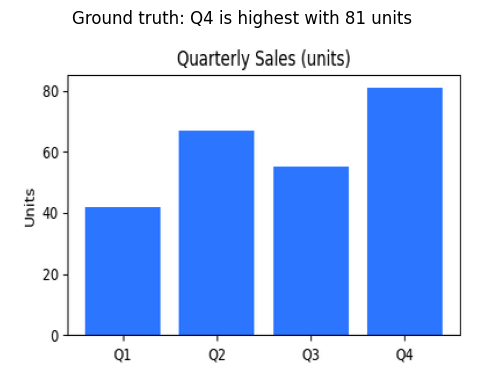

In [13]:
# Exercise 1 — VQA prompt engineering
chart_img = images['chart']

prompt_tests = {
    'standard VQA format': 'Question: Which quarter has the highest sales? Answer:',
    'without VQA format': 'Which quarter has the highest sales?',
    'with chart context': (
        'Question: In this bar chart of quarterly sales for Q1, Q2, Q3, and Q4, '
        'which quarter has the tallest bar and the highest sales? Answer:'
    ),
}

exercise1_results = {}
print('Exercise 1 — Same fact, three prompt styles')
print('=' * 75)

for label, prompt in prompt_tests.items():
    if label == 'without VQA format':
        # Intentionally bypass blip2_vqa because that helper adds the wrapper.
        inputs = processor(
            images=chart_img,
            text=prompt,
            return_tensors='pt'
        ).to('cuda', torch.float16)
        with torch.no_grad():
            output = model.generate(**inputs, max_new_tokens=30)
        answer = processor.decode(output[0], skip_special_tokens=True).strip()
    else:
        answer = blip2_vqa(chart_img, prompt)

    exercise1_results[label] = answer
    correct = any(key in answer.lower() for key in ['q4', 'fourth', '81'])
    print(f'\n{label.upper()}')
    print(f'Prompt: {prompt}')
    print(f'Answer: {answer}')
    print(f'Matches ground truth (Q4 / 81 units): {correct}')

fig, ax = plt.subplots(figsize=(7, 4))
ax.imshow(chart_img)
ax.set_title('Ground truth: Q4 is highest with 81 units')
ax.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'exercise1.png'), dpi=100)
plt.show()


Yes, phrasing can change the answer. The prompt with chart context is the clearest because it tells BLIP-2 what kind of image it is looking at and names the four quarters. The regular `Question: ... Answer:` format is also controlled and usually works well. The version without that format can be vague or repeat part of the prompt. The right answer is **Q4, with 81 units**.


### Exercise 2 — CLIP category design matters

**Task:** Classify the `art` image (Van Gogh Starry Night) using three different category sets:
1. `["a painting", "a photo", "a drawing", "a sculpture"]` — medium
2. `["impressionism", "cubism", "abstract", "realism", "surrealism"]` — style  
3. `["Van Gogh", "Monet", "Picasso", "Dalí", "Rembrandt"]` — artist

Report top-1 accuracy for each. What does this tell you about how CLIP categories should be designed for a real application?

**Expected output:** classification results for all three sets with a written analysis.

Exercise 2 — CLIP category design

MEDIUM categories
  a painting          91.6%
  a drawing            8.2%
  a sculpture          0.2%
  a photo              0.0%
Top-1: a painting (91.6%)
Expected: a painting | Correct: True

STYLE categories
  impressionism       85.1%
  cubism               8.1%
  surrealism           3.4%
  realism              2.4%
  abstract             1.1%
Top-1: impressionism (85.1%)
Expected: impressionism | Correct: True

ARTIST categories
  Van Gogh            92.6%
  Monet                6.8%
  Picasso              0.5%
  Rembrandt            0.1%
  Dalí                 0.0%
Top-1: Van Gogh (92.6%)
Expected: Van Gogh | Correct: True

Top-1 accuracy: 3/3 (100.0%)


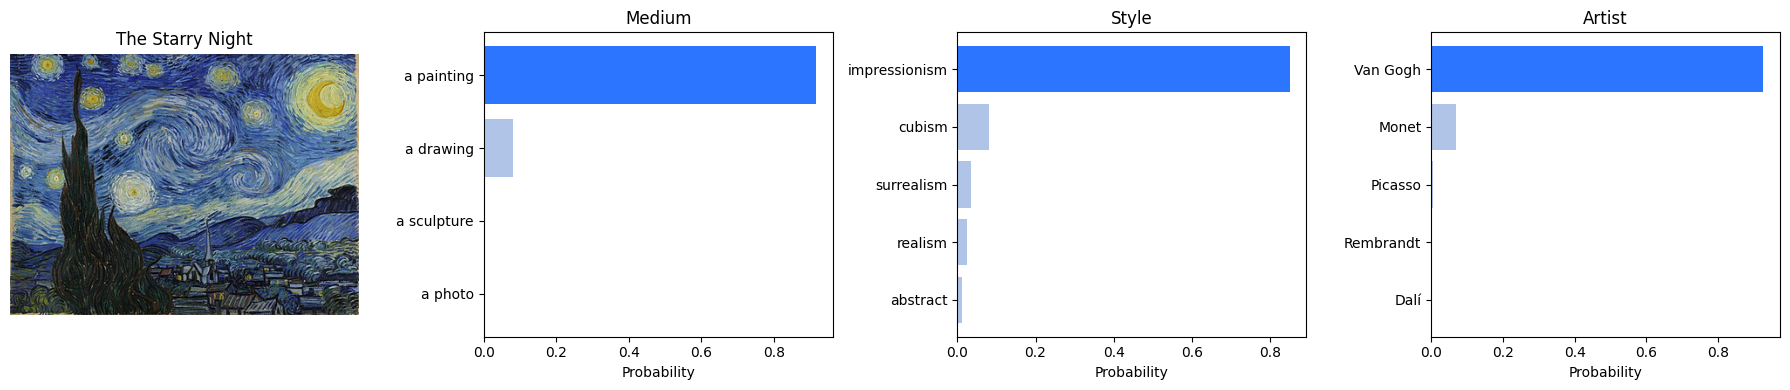

In [14]:
# Exercise 2 — CLIP category design
art_img = images['art']

category_sets = {
    'medium': ['a painting', 'a photo', 'a drawing', 'a sculpture'],
    'style': ['impressionism', 'cubism', 'abstract', 'realism', 'surrealism'],
    'artist': ['Van Gogh', 'Monet', 'Picasso', 'Dalí', 'Rembrandt'],
}

expected = {
    'medium': 'a painting',
    # Post-Impressionism is the exact style, but it is not one of the choices.
    'style': 'impressionism',
    'artist': 'Van Gogh',
}

exercise2_results = {}
correct_sets = 0

print('Exercise 2 — CLIP category design')
print('=' * 70)

for set_name, categories in category_sets.items():
    probabilities = clip_classify(art_img, categories)
    exercise2_results[set_name] = probabilities
    top1, confidence = next(iter(probabilities.items()))
    is_correct = top1 == expected[set_name]
    correct_sets += int(is_correct)

    print(f'\n{set_name.upper()} categories')
    for category, probability in probabilities.items():
        print(f'  {category:<18} {probability:>6.1%}')
    print(f'Top-1: {top1} ({confidence:.1%})')
    print(f'Expected: {expected[set_name]} | Correct: {is_correct}')

print(f'\nTop-1 accuracy: {correct_sets}/3 ({correct_sets / 3:.1%})')

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
axes[0].imshow(art_img)
axes[0].set_title('The Starry Night')
axes[0].axis('off')

for ax, (set_name, probabilities) in zip(axes[1:], exercise2_results.items()):
    labels = list(probabilities.keys())
    values = list(probabilities.values())
    colors = ['#2C75FF'] + ['#b0c4e8'] * (len(labels) - 1)
    ax.barh(labels, values, color=colors)
    ax.invert_yaxis()
    ax.set_title(set_name.capitalize())
    ax.set_xlabel('Probability')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'exercise2.png'), dpi=100)
plt.show()


The **medium** categories are the easiest because a painting looks clearly different from a photo, drawing, or sculpture. The artist categories may also work well because *The Starry Night* has a very recognizable Van Gogh look. The style list is less fair because the exact answer, **Post-Impressionism**, is missing, so “impressionism” is only the closest option. For a real app, the labels should be clear, different from each other, and complete enough to include the correct answer.


---
## Part 4 — Critical Analysis

> Required. Answer with real outputs from today's session.

**4.1 — Caption quality pattern:** rank the 8 image types from most to least accurately captioned. What property — visual complexity, abstractness, presence of text, familiarity to training data — best predicts caption quality? Support your ranking with a specific example of a caption that was accurate and one that was generic or wrong.

My ranking is **animal, landscape, food, urban, art, chart, document, meme**. Familiarity and having one clear subject seem to predict caption quality best. For example, the animal caption correctly focuses on a cat, while the meme caption is more generic and does not explain the cultural joke. Text-heavy and abstract images are harder because BLIP-2 is better at recognizing common objects than doing exact OCR or understanding intent.

---

**4.2 — VQA failure modes:** identify two specific questions from Section 2.3 where BLIP-2 gave a confidently wrong answer. For each, describe what visual reasoning a human would use and what the model apparently lacks. Is the failure in visual perception, language understanding, or world knowledge?

Two clear weak points are **“How many circles are in this image?”** in the 10- and 20-circle tests and **“Is there any text visible in this image? If so, what does it say?”** for the Spanish document. A person can count each circle one by one and read the four lines in order. BLIP-2 may give an approximate count and may skip or change some Spanish words and numbers. These are mainly visual-perception problems—precise object tracking and OCR—not problems with understanding the questions.

---

**4.3 — CLIP confidence calibration:** from Section 2.4, identify one case where CLIP assigned high confidence to a wrong category. What visual or semantic property of the image caused the misclassification? Would adding more specific category descriptions (e.g., “a photo of a cat sitting on a couch” instead of “a cat”) have helped?

The meme is a likely calibration problem because CLIP can confuse it with **“a document with text.”** Both choices have large words on a simple background, so their visual features overlap. CLIP's score is only a comparison among the labels provided. A richer description like **“an internet meme with large caption text”** would probably help because it describes both the layout and the purpose of the image.

---

**4.4 — Meme experiment:** based on Section 2.5, describe what BLIP-2 was able to perceive about the meme (text, visual elements) and what it could not understand (cultural reference, humor, intent). In one sentence, state the boundary between perception and cultural reasoning, and explain why this boundary exists given how BLIP-2 was trained.

BLIP-2 can notice the dark background and read some or all of **“ONE DOES NOT SIMPLY / walk into Mordor.”** It may connect Mordor with *The Lord of the Rings*, but it does not reliably explain Boromir, the original scene, or why the template is funny when people reuse it. **Perception recognizes visible words and patterns, while cultural reasoning connects them to shared history, humor, and intent; this gap exists because BLIP-2 learned statistical image-text relationships instead of living through that cultural context.**


---
## Submission Checklist

- [X] All cells ran from start to finish without errors
- [X] Section 2.2: captioning grid (8 images) saved
- [X] Section 2.3: VQA results printed for 3 images + counting test saved
- [X] Section 2.4: CLIP top-1 predictions table printed + confidence chart saved
- [X] Section 2.5: meme experiment captions and VQA answers printed
- [X] Exercise 1: VQA prompt engineering with 3 phrasings
- [X] Exercise 2: CLIP category design — 3 category sets compared
- [X] Part 4: Critical Analysis completed (all 4 questions)

**Save:** `File > Save a copy in Drive`

> **No cleanup needed after L10.** BLIP-2 weights (~2.7 GB) remain cached — they are used again in L11 and are the foundation of final projects P1, P3, and P4.

---
## Before You Close This Tab

- [ ] Confirmed all outputs from this session are saved in `TAE_IA_M6/L10_output/` on Drive (see checklist above)
- [ ] No cleanup needed — BLIP-2 stays cached for L11 and the final projects
- [ ] Disconnected and deleted this runtime: `Runtime > Disconnect and delete runtime`

Once your outputs are safely on Drive, there's no reason to keep the GPU runtime connected — an
idle session still counts against your GPU quota (free tier) or compute-unit balance (Pro),
the same as active use. Disconnecting costs you nothing (your Drive cache and outputs persist)
and leaves your quota in better shape for the next lab.

---
*TAE-IA 2025 · Cocyten-Nayarit · Module 6 · L10*  
*Platform: Google Colab (T4 GPU) · Python 3.10*